# TFG


- [Simulación mediante EME](FINAL_PROJECT_DEEP_SIN.ipynb)
- [Simulación de la respuesta del circuito en Sax](SAX_SIN.ipynb)
- [Layout](LAYOUT_SIN.ipynb)


En este repositorio se presenta el trabajo final de la asignatura de diseño. El trabajo consta de tres partes principales: simulación mediante EME, simulación de la respuesta del circuito en Sax y layout del circuito. Mediante los enlaces de la celda superior es posible acceder a los notebooks correspomdientes a cada sección. 

# Índice: simulaciones mediante EME


- [Análisis de cross section](#analisis-cross-section)
  - [MMI](#mmi)
    - [Estudio de malla](#estudio-malla)
    - [Obtención de $L_{\pi}$](#lpi)
  - [Guías](#guias)
    - [Obtención de índice de grupo](#indice-grupo)
    - [Waveguide width dependence](#waveguide-width-dependence)
    - [Bend losses analisis](#bend-losses)
- [Optimización](#optimizacion)
  - [MMI 95:05](#mmi-95-05)
  - [MMI 33:33:33](#mmi-33-33-33)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt
import gplugins.tidy3d.materials as mat
from gplugins import plot
from gplugins.common.config import PATH

from upvfab_design_tools import MMI_EME, DC_EME

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)


## Waveguide width dependence

Realmente queremos que haya muy buen confinamiento porque tendremos muchas pérdidas en el brazo largo. Elegimos un width de 1.2.  (tmb porque solemos cogerlo en las simulaciones)

  0%|          | 0/13 [00:00<?, ?it/s]

2026-05-18 12:06:42.263 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_91555884b1d5da38.npz.
2026-05-18 12:06:42.284 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bc28f221a791dd0e.npz.
2026-05-18 12:06:42.287 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_203585dc557d3766.npz.
2026-05-18 12:06:42.291 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_01f69bbe128ede1f.npz.
2026-05-18 12:06:42.293 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c2d44042827f342b.npz.
2026-05-18 12:06:42.296 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_16185d8543a964fc.npz.
2026-05-18 12:06:42.298 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f0828f6f78af6364.npz.
2026-05-18 12:06:42.303 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24b1327d73545743.npz.


  0%|          | 0/13 [00:00<?, ?it/s]

2026-05-18 12:06:42.326 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_91555884b1d5da38.npz.
2026-05-18 12:06:42.329 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bc28f221a791dd0e.npz.
2026-05-18 12:06:42.333 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_203585dc557d3766.npz.
2026-05-18 12:06:42.336 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_01f69bbe128ede1f.npz.
2026-05-18 12:06:42.338 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c2d44042827f342b.npz.
2026-05-18 12:06:42.341 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_16185d8543a964fc.npz.
2026-05-18 12:06:42.343 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f0828f6f78af6364.npz.
2026-05-18 12:06:42.346 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24b1327d73545743.npz.


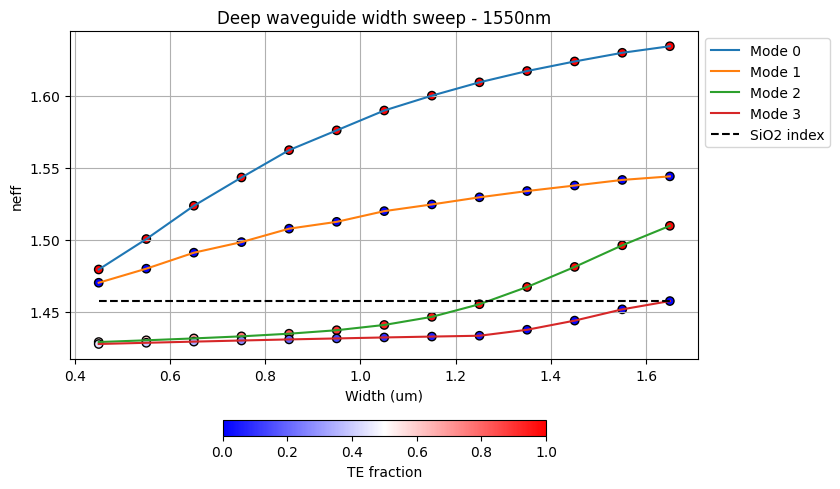

In [2]:
wavelength = 1.55 # Student code here



deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.45,1.65,13) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

<a id="analisis-cross-section"></a>
## Análisis de cross section

<a id="mmi"></a>
### MMI

<a id="estudio-malla"></a>
#### Estudio de malla

Tras la simulación de la malla se decide; grid_resolution = 40 y max_grid_scaliing = 1.45 .

2026-05-18 11:04:58.507 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24c33edd2fbe1881.npz.
2026-05-18 11:04:58.516 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_39b273c5448a402f.npz.
2026-05-18 11:04:58.522 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2c40f9ab444edd2b.npz.
2026-05-18 11:04:58.525 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1f4d5bd178843423.npz.
2026-05-18 11:04:58.532 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c4b58fd0c9d996c5.npz.
2026-05-18 11:04:58.536 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f5ce037f102dc7b6.npz.
2026-05-18 11:04:58.540 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b8b190484d25a0db.npz.


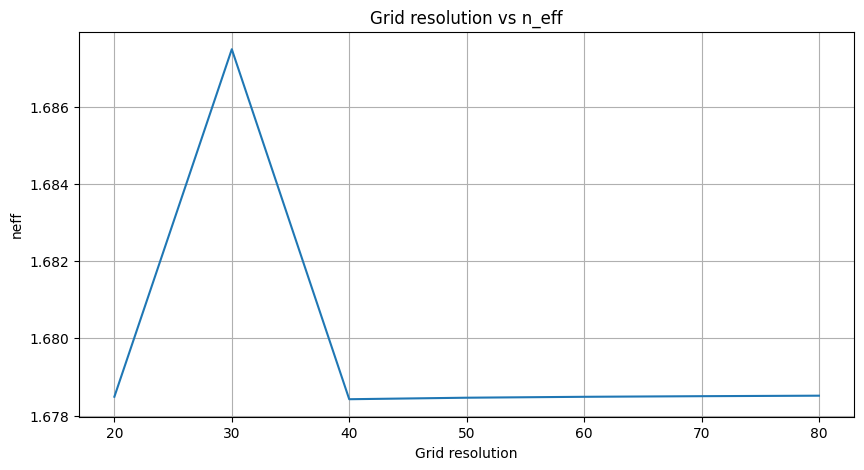

In [6]:
mmi_body_w = 10
lambda_c = 1.55
n_steps = 7
grid_resolution = np.linspace(20,80,n_steps)
res_neff = []

for i in range(n_steps): 
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.2, # Parameters of the grid
        grid_resolution=grid_resolution[i], # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= mmi_body_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"Grid resolution vs n_eff")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()
plt.plot(grid_resolution, res_neff)

2026-05-18 11:05:03.626 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2c40f9ab444edd2b.npz.
2026-05-18 11:05:03.631 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_22a3ad30c6ca35bf.npz.
2026-05-18 11:05:03.636 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7329da91ae8f46b5.npz.
2026-05-18 11:05:03.642 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24acf4d4c2c0ca94.npz.
2026-05-18 11:05:03.646 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_13194a9bce33ff22.npz.
2026-05-18 11:05:03.648 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_162c8f788cee3692.npz.
2026-05-18 11:05:03.650 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_31d979412394fa4b.npz.


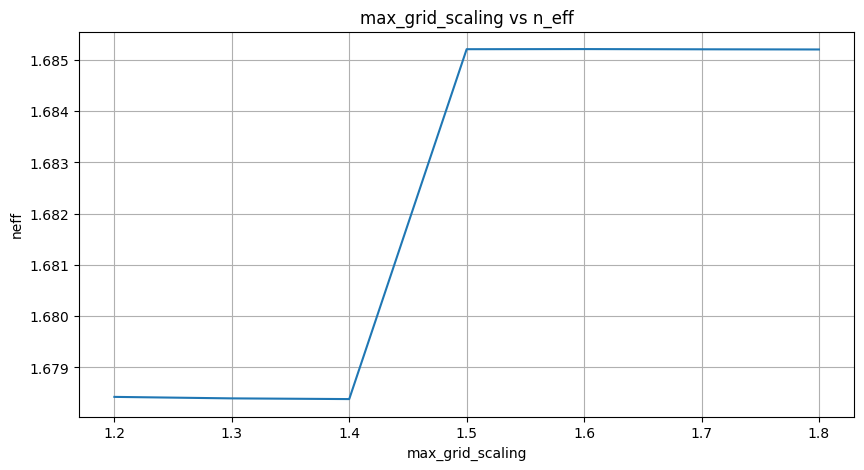

In [7]:
n_steps = 7
max_grid_scaling = np.linspace(1.2,1.8,n_steps)
res_neff = []


for i in range(n_steps): 
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid
        grid_resolution=40, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= mmi_body_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-05-18 11:07:51.881 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_108e6feb9bd5cb8b.npz.
Fracción TE: [0.99998801 0.99995117]


array([1.67835755+7.78501263e-05j, 1.67331589+7.82577262e-05j])

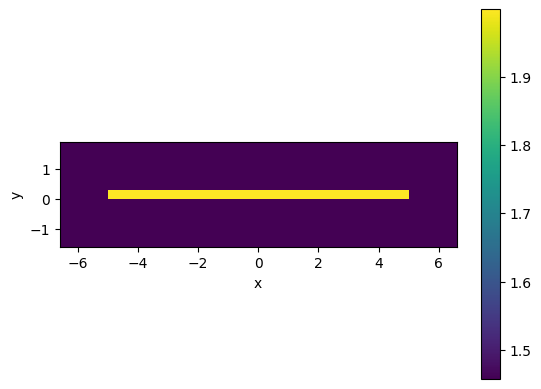

In [8]:
mmi_body_w = 10
lambda_c = 1.55

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.45, # Parameters of the grid
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
pol = mmi_body_waveguide.fraction_te
print(f'Fracción TE: {pol}')
mmi_body_waveguide.n_eff

<a id="lpi"></a>
#### Obtención de $L_{\pi}$

In [9]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

153.71944910050703


<a id="guias"></a>
### Guías


Para la simulación de las guías también se ha hecho un estudio de malla previo tras el que se ha decidido usar: grif_resolution = 40 y max_grid_sacling = 1.45 

2026-05-18 12:14:56.656 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e182eae723c8cc1b.npz.


array(1.6053207)

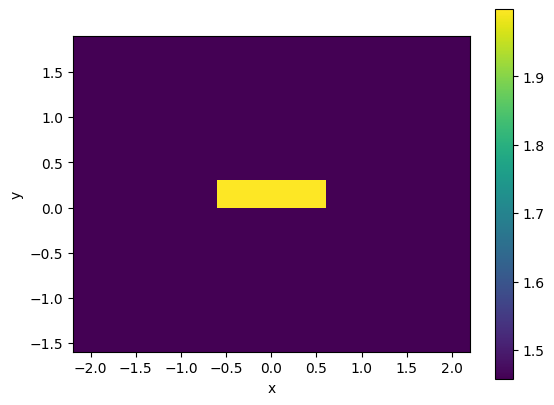

In [9]:
lambda_c = 1.55

deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.45, # Parameters of the grid 
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()
deep_waveguide.n_eff.real

2026-05-18 12:13:15.051 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_17cb1fa5abd35339.npz.
2026-05-18 12:13:15.052 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_73cc7afbf4b6505e.npz.
2026-05-18 12:13:15.053 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c37576520e09004b.npz.
2026-05-18 12:13:15.054 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_070424c9ed5f8f25.npz.


2026-05-18 12:13:15.055 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_53cf1a1fe0a8bb45.npz.
2026-05-18 12:13:15.056 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5233ee167d20737b.npz.
2026-05-18 12:13:15.056 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f7bcdb78ac237ef4.npz.


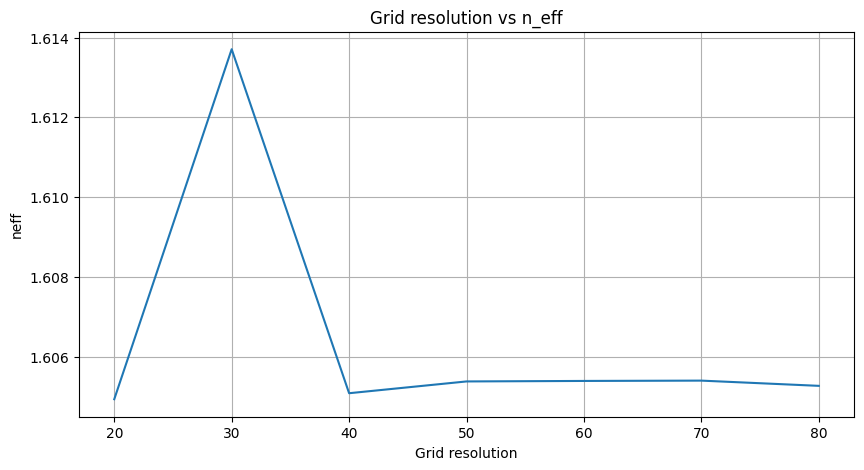

In [4]:
lambda_c = 1.55
n_steps = 7
grid_resolution = np.linspace(20,80,n_steps)
res_neff = []

for i in range(n_steps): 
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=1.2, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.2, # Parameters of the grid
        grid_resolution=grid_resolution[i], # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= deep_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"Grid resolution vs n_eff")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()
plt.plot(grid_resolution, res_neff)

2026-05-18 12:14:00.747 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c37576520e09004b.npz.
2026-05-18 12:14:00.749 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ecb44b7305157b05.npz.
2026-05-18 12:14:00.754 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_67650a03dae08426.npz.
2026-05-18 12:14:00.757 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4a7cfe924ea84b0e.npz.
2026-05-18 12:14:00.762 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bdc4b11664bbcf39.npz.
2026-05-18 12:14:00.765 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6195d13719f4ed74.npz.
2026-05-18 12:14:00.768 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_60a5c3f28fc5e9ec.npz.


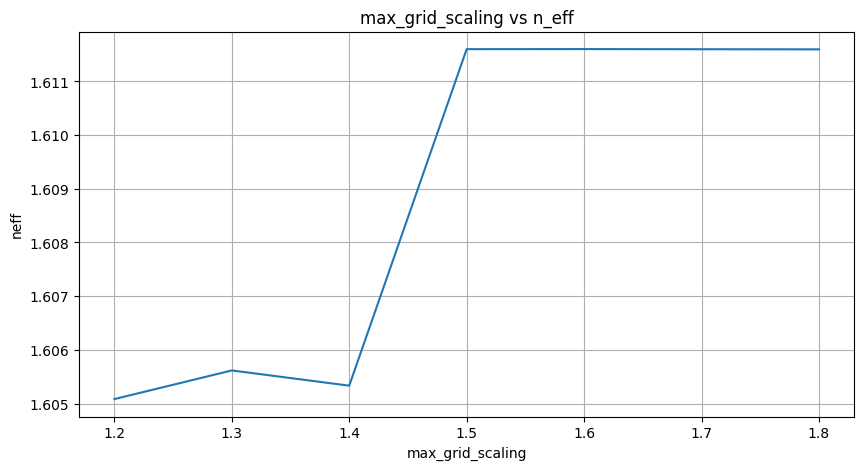

In [7]:
n_steps = 7
max_grid_scaling = np.linspace(1.2,1.8,n_steps)
res_neff = []


for i in range(n_steps): 
    deep_waveguide= gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=1.2 ,# MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid
        grid_resolution=40, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= deep_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

<a id="indice-grupo"></a>
#### Obtención de índice de grupo

In [10]:
wl = np.linspace(1.5,1.6, 200)

deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=wl, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.45, # Parameters of the grid 
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

neff = deep_waveguide.n_eff.real




ng = neff - wl * np.gradient(neff, wl)

print(ng)

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-05-18 12:22:44.137 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_50c35e2475245554.npz.
[1.95482584 1.95475309 1.95460756 1.95446198 1.95431636 1.95417069
 1.95402497 1.95387921 1.9537334  1.95358755 1.95344165 1.9532957
 1.9531497  1.95300366 1.95285757 1.95271144 1.95256526 1.95241903
 1.95227276 1.95212644 1.95198008 1.95183367 1.95168721 1.9515407
 1.95139416 1.95124756 1.95110092 1.95095423 1.9508075  1.95066072
 1.9505139  1.95036703 1.95022011 1.95007315 1.94992614 1.94977909
 1.94963199 1.94948484 1.94933765 1.94919042 1.94904314 1.94889581
 1.94874844 1.94860103 1.94845356 1.94830606 1.9481585  1.94801091
 1.94786326 1.94771558 1.94756784 1.94742007 1.94727224 1.94712438
 1.94697646 1.94682851 1.94668051 1.94653246 1.94638437 1.94623623
 1.94608805 1.94593982 1.94579155 1.94564324 1.94549488 1.94534648
 1.94519803 1.94504954 1.944901   1.94475242 1.9446038  1.94445513
 1.94430642 1.94415766 1.94400886 1.94386001 1.94371112 1.94356219
 1.94

In [11]:
print(neff)

[1.61639292 1.61627954 1.61616621 1.61605293 1.6159397  1.61582652
 1.61571338 1.6156003  1.61548726 1.61537427 1.61526133 1.61514844
 1.6150356  1.61492281 1.61481006 1.61469737 1.61458472 1.61447212
 1.61435957 1.61424707 1.61413462 1.61402222 1.61390986 1.61379756
 1.6136853  1.61357309 1.61346093 1.61334882 1.61323676 1.61312474
 1.61301278 1.61290086 1.61278899 1.61267718 1.61256541 1.61245368
 1.61234201 1.61223039 1.61211881 1.61200729 1.61189581 1.61178438
 1.611673   1.61156167 1.61145038 1.61133915 1.61122796 1.61111682
 1.61100574 1.6108947  1.61078371 1.61067276 1.61056187 1.61045102
 1.61034023 1.61022948 1.61011878 1.61000813 1.60989753 1.60978698
 1.60967647 1.60956602 1.60945561 1.60934525 1.60923494 1.60912468
 1.60901447 1.6089043  1.60879419 1.60868412 1.6085741  1.60846414
 1.60835422 1.60824434 1.60813452 1.60802475 1.60791502 1.60780534
 1.60769571 1.60758614 1.6074766  1.60736712 1.60725769 1.6071483
 1.60703897 1.60692968 1.60682044 1.60671125 1.60660211 1.60649

In [12]:
# índice de grupo a wl=1.55
idx = np.argmin(abs(wl - 1.55))
ng_wl0 = ng[idx]
print(ng_wl0)

1.9402746464845069


In [13]:
# Cálculo de la diferencia de longitud de brazos necesaria para obtener un FSR de 10 pm con los datos simulados.
FSR = 1e-5 #um = 10pm
wl0 = 1.55

AL = (wl0**2)/(ng_wl0*FSR)

print(f'AL = {AL}')

AL = 123822.6765655562


<a id="optimizacion"></a>
## Optimización

En la siguiente sección se ha realizado la optimización de los MMI's con el fin de obtener las relaciones de potencia deseadas  y reducir las pérdidas al máximo. 

<a id="mmi-95-05"></a>
### MMI 95:05

Cabe destacar que sería interesante utilizar una geometría "Tipo B Simétrica" para el diseño del MMI con splitting ratio de 95:05 ya que permitiría obtener dicha relación de potencia con pérdidas mucho menores. En esta sección se ha llevado a cabo la simulación usando una geometría rectangular estándar. Se demuestra que el uso de esta geometría conlleva unas pérdidas significativas incluso tras la optimización. En las siguientes fases del diseño se asume que se han podido optimizar las pérdidas de forma adecuada usando la geometría rectangular.

In [14]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 10  # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width=2.7
m.MMI_num_modes = 40 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.VERBOSE = True
m.find_all_modes()

# 2) Get the L_pi 
L_pi_eme = m.get_L_pi()


[Mode(k: (6.5261051643783246+0j), n_eff:(1.609925938874953+0j)), Mode(k: (6.505221506434923+0j), n_eff:(1.6047741459180773+0j)), Mode(k: (6.47034276388493+0j), n_eff:(1.5961699032753027+0j)), Mode(k: (6.421370963511184+0j), n_eff:(1.5840890419178364+0j)), Mode(k: (6.358197020260381+0j), n_eff:(1.5685046516362293+0j)), Mode(k: (6.280752339927785+0j), n_eff:(1.5493998109150178+0j)), Mode(k: (6.189133233715205+0j), n_eff:(1.526798278780158+0j)), Mode(k: (6.172639472943727+0j), n_eff:(1.5227294302668761+0j)), Mode(k: (6.15265470601171+0j), n_eff:(1.5177993848790325+0j)), Mode(k: (6.119386516077944+0j), n_eff:(1.5095924497217306+0j)), Mode(k: (6.0839897947043164+0j), n_eff:(1.5008604267991483+0j)), Mode(k: (6.072961785803351+0j), n_eff:(1.4981399254991208+0j)), Mode(k: (6.013769729695636+0j), n_eff:(1.4835378276010815+0j)), Mode(k: (5.968543226735531+0j), n_eff:(1.472380894268547+0j))]
Wavelength 1.55  µm
---------------------------------------------
Core refractive index: 1.998342587714340

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


n_MODES= 9
Lπ 2D = 150.43 µm
[Mode(k: (6.5261051643783246+0j), n_eff:(1.609925938874953+0j)), Mode(k: (6.505221506434923+0j), n_eff:(1.6047741459180773+0j)), Mode(k: (6.47034276388493+0j), n_eff:(1.5961699032753027+0j)), Mode(k: (6.421370963511184+0j), n_eff:(1.5840890419178364+0j)), Mode(k: (6.358197020260381+0j), n_eff:(1.5685046516362293+0j)), Mode(k: (6.280752339927785+0j), n_eff:(1.5493998109150178+0j)), Mode(k: (6.189133233715205+0j), n_eff:(1.526798278780158+0j)), Mode(k: (6.172639472943727+0j), n_eff:(1.5227294302668761+0j)), Mode(k: (6.15265470601171+0j), n_eff:(1.5177993848790325+0j)), Mode(k: (6.119386516077944+0j), n_eff:(1.5095924497217306+0j)), Mode(k: (6.0839897947043164+0j), n_eff:(1.5008604267991483+0j)), Mode(k: (6.072961785803351+0j), n_eff:(1.4981399254991208+0j)), Mode(k: (6.013769729695636+0j), n_eff:(1.4835378276010815+0j)), Mode(k: (5.968543226735531+0j), n_eff:(1.472380894268547+0j))]


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3009 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 0.0000
IO wg width 2.7000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9999
Total OUT power: 0.9817
Excess loss [dB] =  0.0800
------------------------
Power over OUTs:  ['0.0002', '0.9816']
Ratio over OUTs ['0.0002', '0.9998']


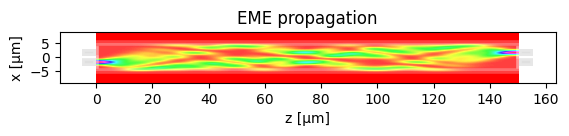

In [15]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)

m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT
m.dL_MMI = 0
dy = 0
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-1.68, 1.68]) # STUDENT
m.OUT_WVG_positions =np.array([-1.68, 1.68])# STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi_eme


# Run propagation
m.propagation()

Párametros escogidos para el diseño del circuito: 

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3249 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 12.0000
IO wg width 2.8000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0000
Total OUT power: 0.5546
Excess loss [dB] =  2.5603
------------------------
Power over OUTs:  ['0.0322', '0.5224']
Ratio over OUTs ['0.0581', '0.9419']


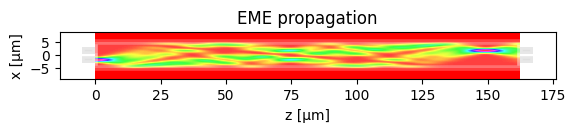

In [31]:

dy = 0.1

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-1.68, 1.68]) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = np.array([-1.68, 1.68]) + np.array([-dy, dy]) # STUDENT4
m.wg_width = 2.8

# MMI length (check class slides for type of MMI)
m.dL_MMI = 12 # STUDENT

# Run propagation
m.propagation()

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3249 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 12.0000
IO wg width 2.4000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9976
Total OUT power: 0.5028
Excess loss [dB] =  2.9864
------------------------
Power over OUTs:  ['0.0370', '0.4658']
Ratio over OUTs ['0.0736', '0.9264']


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


...

------- Pameters -------
MMI length 150.4331
MMI length increment 12.0000
IO wg width 2.7000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0000
Total OUT power: 0.5546
Excess loss [dB] =  2.5603
------------------------
Power over OUTs:  ['0.0322', '0.5224']
Ratio over OUTs ['0.0581', '0.9419']


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3249 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 12.0000
IO wg width 2.8000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0001
Total OUT power: 0.5723
Excess loss [dB] =  2.4237
------------------------
Power over OUTs:  ['0.0309', '0.5414']
Ratio over OUTs ['0.0540', '0.9460']


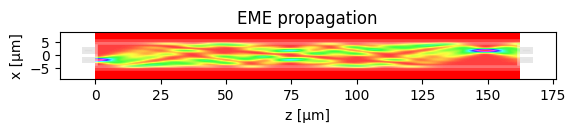

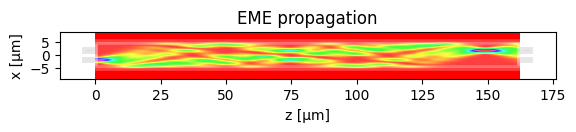

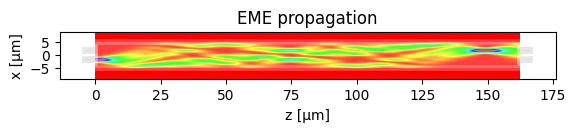

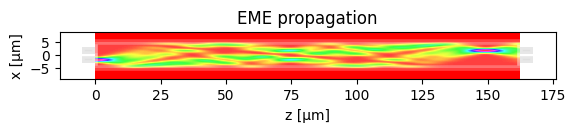

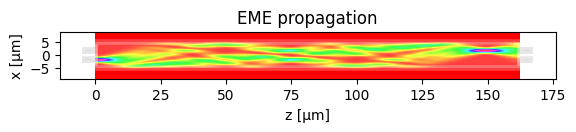

In [3]:
widths = [2.4, 2.5, 2.6, 2.7, 2.8]
mmi_Width = 10

for dw in widths:
    m = MMI_EME() 
    m.MMI_width = mmi_Width
    m.wg_width=dw
    m.MMI_num_modes = 30
    
    m.find_all_modes()
    L_pi_eme = m.get_L_pi()

    m.n_IN = 2 
    m.n_OUT = 2 
    
    dy = 0.1
    m.IN_WVG_positions = np.array([-1.68, 1.68]) + np.array([-dy, dy])
    m.OUT_WVG_positions = np.array([-1.68, 1.68]) + np.array([-dy, dy])
    
    m.L_MMI = L_pi_eme
    m.dL_MMI = 12
    
    m.propagation()

<a id="mmi-33-33-33"></a>
### MMI 33:33:33

In [4]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 10  # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width

m.wg_width=2
m.MMI_num_modes = 40 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
#m.VERBOSE = True
m.find_all_modes()

# 2) Get the L_pi 
L_pi_eme = m.get_L_pi()

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3009 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 0.0000
IO wg width 2.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9894
Total OUT power: 0.6444
Excess loss [dB] =  1.9083
------------------------
Power over OUTs:  ['0.0949', '0.2267', '0.3228']
Ratio over OUTs ['0.1472', '0.3518', '0.5010']


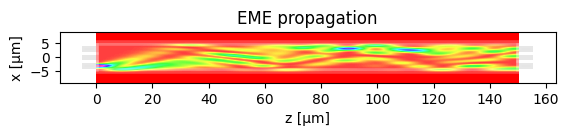

In [5]:
m.dL_MMI = 0
dy = 0
m.n_IN = 3
m.n_OUT = 3

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-3, 0, 3])
m.OUT_WVG_positions =np.array([-3, 0,  3])

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi_eme


# Run propagation
m.propagation()

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3079 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 3.5000
IO wg width 2.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9985
Total OUT power: 0.7254
Excess loss [dB] =  1.3943
------------------------
Power over OUTs:  ['0.2515', '0.2316', '0.2423']
Ratio over OUTs ['0.3467', '0.3193', '0.3341']


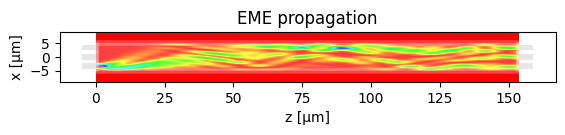

In [40]:

dy = 0.35

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy]) # STUDENT
m.OUT_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy,0, dy]) # STUDENT4


# MMI length (check class slides for type of MMI)
m.dL_MMI = 3.5 # STUDENT

# Run propagation
m.propagation()

Parámetros escogidos para el diseño del circuito: parámetros correspondientes a wg_width = 2.8 .

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/4849 [00:00<?, ?it/s]

------- Pameters -------
MMI length 245.9723
MMI length increment -3.5000
IO wg width 2.4000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9987
Total OUT power: 0.9785
Excess loss [dB] =  0.0943
------------------------
Power over OUTs:  ['0.3258', '0.3278', '0.3249']
Ratio over OUTs ['0.3330', '0.3350', '0.3320']


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


...

------- Pameters -------
MMI length 245.9723
MMI length increment -3.5000
IO wg width 2.7000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9990
Total OUT power: 0.9808
Excess loss [dB] =  0.0844
------------------------
Power over OUTs:  ['0.3282', '0.3236', '0.3289']
Ratio over OUTs ['0.3347', '0.3299', '0.3354']


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/4849 [00:00<?, ?it/s]

------- Pameters -------
MMI length 245.9723
MMI length increment -3.5000
IO wg width 2.8000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9991
Total OUT power: 0.9814
Excess loss [dB] =  0.0816
------------------------
Power over OUTs:  ['0.3291', '0.3218', '0.3305']
Ratio over OUTs ['0.3354', '0.3279', '0.3367']


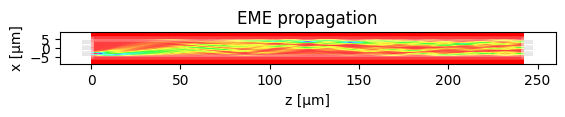

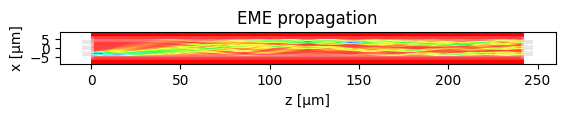

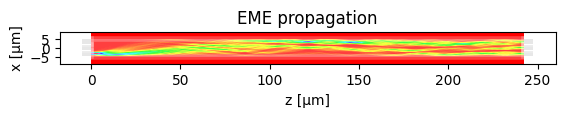

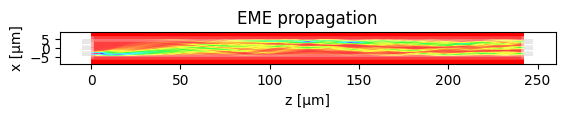

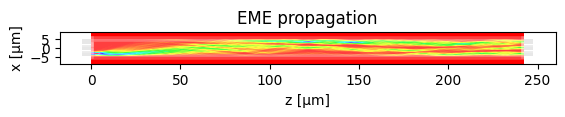

In [ ]:
widths = [2.4, 2.5, 2.6, 2.7, 2.8] ############# 2.8 ELEGIDO COMO OPTIMIZADO !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!1
mmi_Width = 10

for dw in widths:
    m = MMI_EME() 
    m.MMI_width = mmi_Width
    m.wg_width=dw
    m.MMI_num_modes = 30
    
    m.find_all_modes()
    L_pi_eme = m.get_L_pi()

    m.n_IN = 3
    m.n_OUT = 3
    
    dy = 0.35
    m.IN_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy])
    m.OUT_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy])
    
    m.L_MMI = L_pi_eme
    m.dL_MMI = 3.5
    
    m.propagation()